In [22]:
import numpy as np
import matplotlib.pyplot as plt


def plot_exponential(
    t: np.ndarray,
    r1: complex,
    r2: complex,
    C1: complex,
    C2: complex,
    title: str = None,
):
    y1 = C1 * np.exp(r1 * t)
    y2 = C2 * np.exp(r2 * t)
    y_sum = y1 + y2

    fig, axes = plt.subplots(
        nrows=3,
        ncols=1,
        figsize=(8, 8),
        sharex=True
    )

    signals = [
        (y1, r"$y_1=C_1e^{r_1t}$"),
        (y2, r"$y_2=C_2e^{r_2t}$"),
        (y_sum, r"$y_1+y_2$")
    ]

    for ax, (y, label) in zip(axes, signals):

        # Real part
        ax.plot(
            t,
            np.real(y),
            "-",
            linewidth=2,
            label=f"Re({label})"
        )

        # Imaginary part (only if nonzero)
        if np.any(np.abs(np.imag(y)) > 1e-12):
            ax.plot(
                t,
                np.imag(y),
                "--",
                linewidth=2,
                label=f"Im({label})"
            )

        ax.set_ylabel("Amplitude")
        ax.legend()

    axes[-1].set_xlabel("time [s]")

    if title:
        fig.suptitle(title)

    plt.tight_layout()
    plt.show()

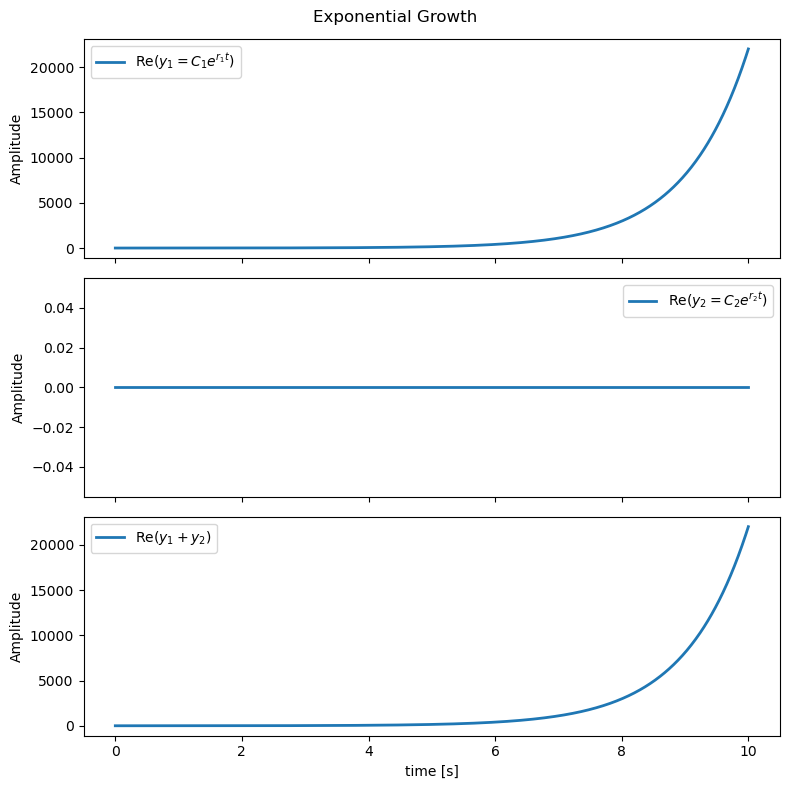

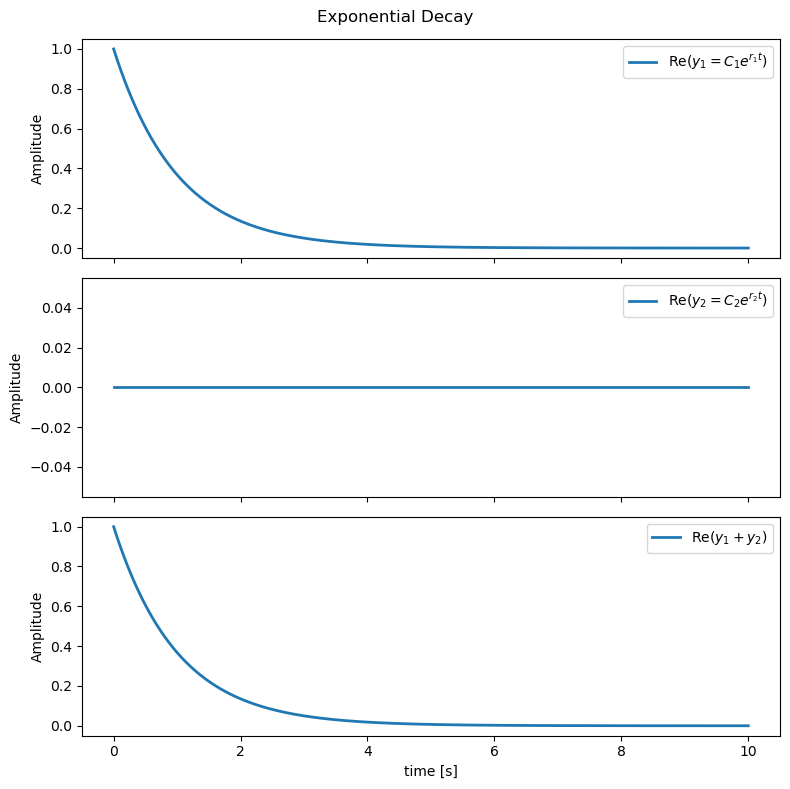

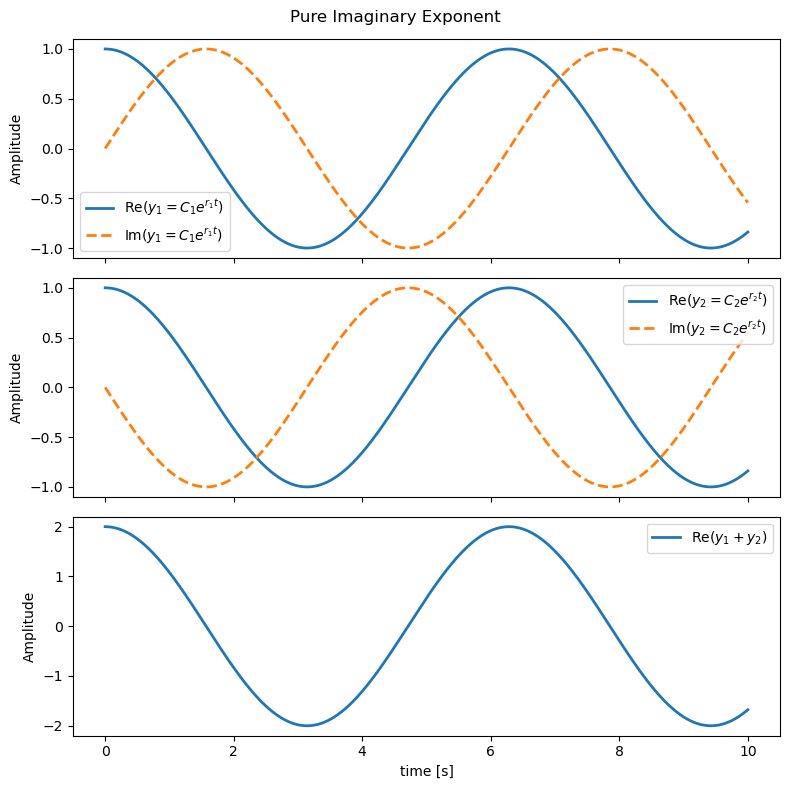

In [26]:
t = np.linspace(0, 10, 1000)

# Exponential growth
plot_exponential(
    t,
    r1=1,
    r2=0,
    C1=1,
    C2=0,
    title="Exponential Growth"
)

# Exponential decay
plot_exponential(
    t,
    r1=-1,
    r2=0,
    C1=1,
    C2=0,
    title="Exponential Decay"
)

# Oscillation from imaginary exponent
plot_exponential(
    t,
    r1=1j,
    r2=-1j,
    C1=1,
    C2=1,
    title="Pure Imaginary Exponent"
)

In [27]:
def solve_2ndOrder_ODE(t, a, b, c, C1=1, C2=1):
    r1, r2 = np.roots([a, b, c])

    # repeated root
    if np.isclose(r1, r2):
        r = r1
        y = (C1 + C2*t) * np.exp(r*t)

    # distinct roots
    else:
        y = C1*np.exp(r1*t) + C2*np.exp(r2*t)

    return r1, r2

In [ ]:
# overdamped
t = np.linspace(0, 10, 1000)

C1 = 1.
C2 = 2.
r1, r2 = solve_2ndOrder_ODE(
    t=t,
    a=1,
    b=3,
    c=2,
    C1=1,
    C2=1
)

plot_exponential()
